In [28]:
%reload_ext autoreload
%autoreload 2

from PIL import Image
from vangogh.evolution import Evolution
from vangogh.fitness import draw_voronoi_image
from vangogh.util import IMAGE_SHRINK_SCALE, REFERENCE_IMAGE
from IPython.display import display, clear_output
import numpy as np
import pandas as pd
import seaborn as sns
import collections
import collections
import matplotlib.pyplot as plt
from time import time
from mpl_toolkits.axes_grid1 import ImageGrid
plt.style.use('classic')
%matplotlib inline

from multiprocess import Pool, cpu_count

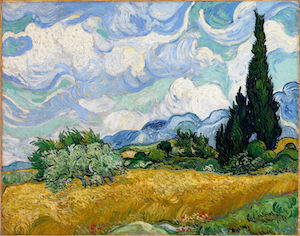

In [29]:
display(REFERENCE_IMAGE)

In [30]:
# Enable to show live rendering of best individual during optimization
display_output = False
# Enable to save progress images at every 50th generation
save_progress = True
# Enable to print verbose output per generation
verbose_output = True

In [31]:
def reporter(time, evo):
    if save_progress or display_output:
        elite = draw_voronoi_image(evo.elite, evo.reference_image.width, evo.reference_image.height, scale=IMAGE_SHRINK_SCALE)
    if display_output:
        clear_output()
        display(elite)
    if save_progress and time["num-generations"] % 50 == 0:
        elite.save(f"./final_img/van_gogh_intermediate_seed{evo.seed}_ea-{evo.evolution_type}_sel{evo.selection_name}_mutS{evo.num_features_mutation_strength}_{evo.population_size}_{evo.crossover_method}_{evo.num_points}_{evo.initialization}_{evo.generation_budget}_{time['num-generations']:05d}.png")


# my version with selection setting
def run_algorithm(settings):
    seed, population_size, crossover_method, num_points, initialization, generation_budget, selection_name, num_features_mutation_strength, evolution_type = settings
    start = time()
    data = []
    evo = Evolution(num_points,
                    REFERENCE_IMAGE,
                    population_size=population_size,
                    generation_reporter=reporter,
                    crossover_method=crossover_method,
                    seed=seed,
                    initialization=initialization,
                    generation_budget=generation_budget,
                    num_features_mutation_strength=num_features_mutation_strength,#.25,
                    selection_name=selection_name,
                    evolution_type=evolution_type,
                    verbose=verbose_output)
    data = evo.run()
    time_spent = time() - start
    print(f"Done: seed {seed} - pop {population_size} - gen budget {generation_budget} - crossover {crossover_method} - num. points {num_points} - initialization {initialization} - selection {selection_name} - in {int(time_spent)} seconds")
    return data


## Running a single instance

In [ ]:
# %%time
# data = run_algorithm((0, 100, "ONE_POINT", 100, 'RANDOM', 500))

## Running a sweep of settings

In [ ]:


# generation_budget = 10
# population_size = 100
# crossover_method = "ONE_POINT"
# initialization = "RANDOM"
# num_points = 100
# num_features_mutation_strength = 0.5

# all_results = collections.defaultdict(lambda: collections.defaultdict(list))
# file_name = "truncation_sizes.csv"
# for selection_name, config in selection_experiments.items():
#     for seed in config["seeds"]:
#         print(f"\nRunning {selection_name}, seed {seed}")
#         seed_data = []
#         data = run_algorithm((seed, population_size, crossover_method, num_points, initialization, generation_budget, selection_name,num_features_mutation_strength))
#         seed_data.append(data)
#         all_results[selection_name][seed] = seed_data

## Evaluating the results

### Best of truncation/tournmanet sizes + 0.50 mutation + ssga - 11 seeds

In [56]:
file_name = "./csv/ssga_truncation_tournament_sizes_50_11seeds.csv"

In [57]:
selection_experiments = {
    "truncation_1": {"seeds": list(range(0,240,20))},
    # "truncation_10": {"seeds": list(range(0,240,20))},
    # "tournament_10": {"seeds": list(range(0,240,20))},
}

In [37]:
import os
import csv

generation_budget = 500
population_size = 100
crossover_method = "ONE_POINT"
initialization = "RANDOM"
num_points = 100
num_features_mutation_strength = 0.50
evolution_type="ssga"

fieldnames = [
    "selection-name",
    "num-features-mutation-strength",
    "seed",
    "num-generations",
    "num-evaluations",
    "time-elapsed",
    "best-fitness",
    "avg-fitness",
    "crossover-method",
    "population-size",
    "num-points",
    "initialization",
    "evolution_type",
]
if not os.path.isfile(file_name):
    with open(file_name, "w", newline="") as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()

# -- 3. your experiment loop, writing out each seed as soon as it’s done --
all_results = collections.defaultdict(lambda: collections.defaultdict(list))
for selection_name, config in selection_experiments.items():
    for seed in config["seeds"]:
        print(f"\nRunning {selection_name}, seed {seed}")

        # run your algorithm and get a list of generation‐records:
        data = run_algorithm((
            seed,
            population_size,
            crossover_method,
            num_points,
            initialization,
            generation_budget,
            selection_name,
            num_features_mutation_strength,
            evolution_type
        ))
        all_results[selection_name][seed] = data 
        
        with open(file_name, "a", newline="") as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
            writer.writeheader()

            # -- 3. walk your all_results nested defaultdict --
            for selection_name, seeds in all_results.items():
                for seed, records in seeds.items():
                    for rec in records:
                        # build a flat row, mapping your dict-keys into the CSV columns
                        row = {
                            "selection-name": rec.get("selection-name", rec["selection-name"]),
                            "num-features-mutation-strength": rec["num-features-mutation-strength"],
                            "seed": rec.get("seed", seed),
                            "num-generations": rec["num-generations"],
                            "num-evaluations": rec["num-evaluations"],
                            "time-elapsed": rec["time-elapsed"],
                            "best-fitness": int(rec["best-fitness"]),
                            "avg-fitness": float(rec["avg-fitness"]),
                            "crossover-method": rec["crossover-method"],
                            "population-size": rec["population-size"],
                            "num-points": rec["num-points"],
                            "initialization": rec["initialization"],
                        }
                        writer.writerow(row)



Running tournament_10, seed 0
generation: 1 best fitness: 99189 avg. fitness: 129687.52
generation: 2 best fitness: 98644 avg. fitness: 119975.35
generation: 3 best fitness: 98644 avg. fitness: 108517.36
generation: 4 best fitness: 98644 avg. fitness: 107869.19
generation: 5 best fitness: 98644 avg. fitness: 107811.35
generation: 6 best fitness: 98644 avg. fitness: 107448.34
generation: 7 best fitness: 98644 avg. fitness: 107104.3
generation: 8 best fitness: 98644 avg. fitness: 106759.85
generation: 9 best fitness: 98644 avg. fitness: 106646.96
generation: 10 best fitness: 98644 avg. fitness: 106646.96
generation: 11 best fitness: 98644 avg. fitness: 106199.94
generation: 12 best fitness: 98644 avg. fitness: 105555.26
generation: 13 best fitness: 98644 avg. fitness: 105368.71
generation: 14 best fitness: 98644 avg. fitness: 105301.7
generation: 15 best fitness: 98644 avg. fitness: 104941.23
generation: 16 best fitness: 92913 avg. fitness: 104764.93
generation: 17 best fitness: 92913 a

/home/sanchita/EA/evolutionary-van-gogh/vangogh/fitness.py:23: RuntimeWarning: overflow encountered in scalar multiply
  coords.append((x * scale, y * scale))


generation: 248 best fitness: 90948 avg. fitness: 93427.01
generation: 249 best fitness: 90948 avg. fitness: 93427.01
generation: 250 best fitness: 90948 avg. fitness: 93427.01
generation: 251 best fitness: 90948 avg. fitness: 93379.98
generation: 252 best fitness: 90948 avg. fitness: 93379.98
generation: 253 best fitness: 90948 avg. fitness: 93379.98
generation: 254 best fitness: 90948 avg. fitness: 92597.56
generation: 255 best fitness: 90948 avg. fitness: 92597.56
generation: 256 best fitness: 90948 avg. fitness: 92597.56
generation: 257 best fitness: 90948 avg. fitness: 92597.56
generation: 258 best fitness: 90948 avg. fitness: 92597.56
generation: 259 best fitness: 90948 avg. fitness: 92597.56
generation: 260 best fitness: 90948 avg. fitness: 92597.56
generation: 261 best fitness: 90948 avg. fitness: 92597.56
generation: 262 best fitness: 90948 avg. fitness: 92597.56
generation: 263 best fitness: 90948 avg. fitness: 92597.56
generation: 264 best fitness: 90948 avg. fitness: 92597.

In [58]:
import pandas as pd

# load
df = pd.read_csv(file_name)

# isolate the “final” row per (selection_method, seed)
#    We sort by generation then take the last row in each group:
final_per_seed = (
    df
    .sort_values("num-generations")
    .groupby(["selection-name", "seed"], as_index=False)
    .last()
)

# final_per_seed

# 3. now group *only* by selection_method and compute mean±std
summary = final_per_seed.groupby("selection-name").agg({
    "best-fitness":     ["mean", "std"],
    "avg-fitness":      ["mean", "std"],
    "num-evaluations":  ["mean", "std"],
    "num-generations":  ["mean", "std"],
}).reset_index()

In [41]:
final_per_seed

,selection-name,seed,num-features-mutation-strength,num-generations,num-evaluations,time-elapsed,best-fitness,avg-fitness,crossover-method,population-size,num-points,initialization,evolution_type
0,tournament_10,0,0.5,500,25100,2003.602689,90948,92527.27,ONE_POINT,100,100,RANDOM,NaN
1,tournament_10,20,0.5,500,25100,1980.070641,92529,93525.88,ONE_POINT,100,100,RANDOM,NaN
2,tournament_10,40,0.5,500,25100,1970.680157,97760,98725.43,ONE_POINT,100,100,RANDOM,NaN
3,tournament_10,60,0.5,500,25100,2102.614244,91693,98728.84,ONE_POINT,100,100,RANDOM,NaN
4,tournament_10,80,0.5,500,25100,2101.362883,92513,98981.99,ONE_POINT,100,100,RANDOM,NaN
5,tournament_10,100,0.5,500,25100,2122.372425,96656,98856.07,ONE_POINT,100,100,RANDOM,NaN
6,tournament_10,120,0.5,500,25100,2099.342993,80844,93833.90,ONE_POINT,100,100,RANDOM,NaN
7,tournament_10,140,0.5,500,25100,2003.658951,88260,97714.93,ONE_POINT,100,100,RANDOM,NaN
8,tournament_10,160,0.5,500,25100,1963.470926,88656,88656.00,ONE_POINT,100,100,RANDOM,NaN
9,tournament_10,180,0.5,500,25100,1960.444831,88716,98608.48,ONE_POINT,100,100,RANDOM,NaN


In [42]:
summary

selection-name  best-fitness                avg-fitness               \
                          mean          std          mean          std   
0  tournament_10  91506.916667  4717.014299  96440.789167  3430.908961   
1   truncation_1  32594.916667   801.053563  32604.740833   798.787099   

  num-evaluations      num-generations       
             mean  std            mean  std  
0         25100.0  0.0           500.0  0.0  
1         25100.0  0.0           500.0  0.0

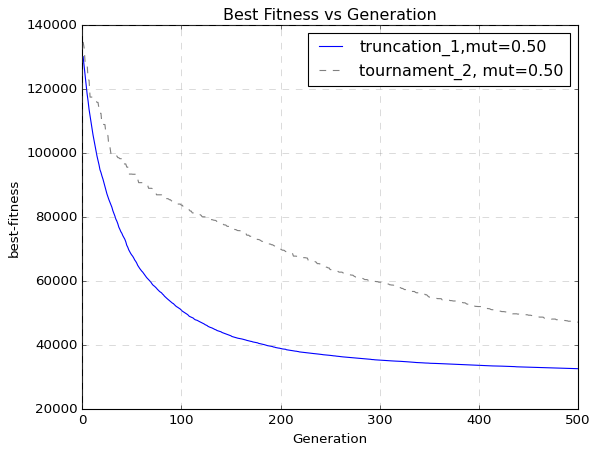

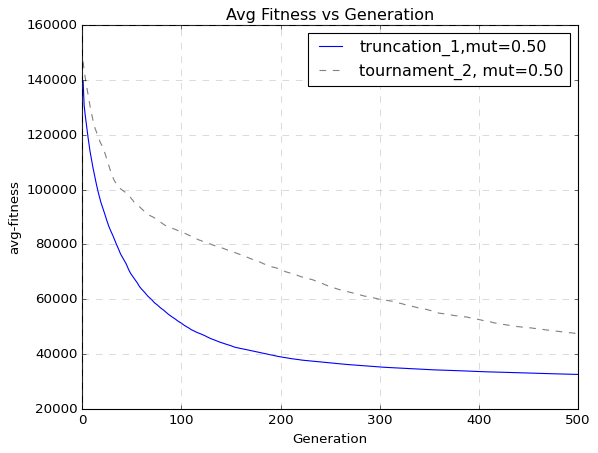

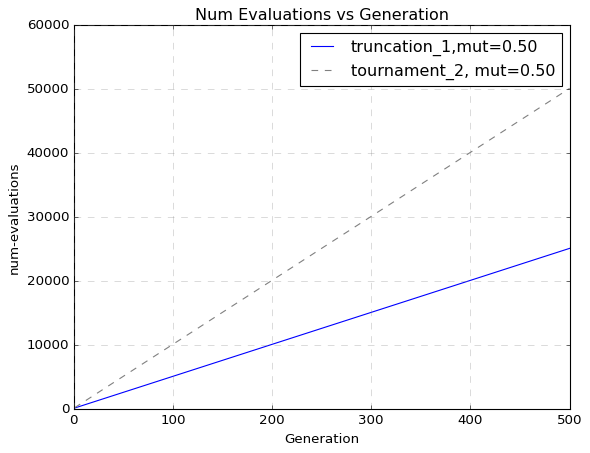

In [59]:
# Compute mean across seeds for each selection method and generation
mean_df = (
    df
    .groupby(["selection-name", "num-generations"], as_index=False)
    .agg({
        "best-fitness": "mean",
        "avg-fitness": "mean",
        "num-evaluations": "mean"
    })
)

# load baseline
df_base = pd.read_csv("./csv/base50.csv")

# compute baseline mean per generation
base_mean_df = (
    df_base
    .groupby("num-generations", as_index=False)
    .agg({
        "best-fitness":     "mean",
        "avg-fitness":      "mean",
        "num-evaluations":  "mean"
    })
)
import matplotlib as mpl
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor']   = 'white'
# turn on major grid by default
mpl.rcParams['axes.grid']        = True
# optional: set style of those grid‐lines
mpl.rcParams['grid.linestyle']   = '--'
mpl.rcParams['grid.color']       = 'grey'
mpl.rcParams['grid.alpha']       = 0.5

# Plot each metric
for metric in ["best-fitness", "avg-fitness", "num-evaluations"]:
    plt.figure()
    for method in selection_experiments.keys():
        if method == "tournament_10":
            continue
        sub = mean_df[mean_df["selection-name"] == method]
        plt.plot(sub["num-generations"], sub[metric], label=method+",mut=0.50")

    # plot baseline
    plt.plot(base_mean_df["num-generations"],
             base_mean_df[metric],
             linestyle='--',
             color='grey',
             label='tournament_2, mut=0.50')
    
    plt.xlabel("Generation")
    plt.ylabel(metric)
    plt.title(f"{metric.replace('-', ' ').title()} vs Generation")
    plt.legend()
    plt.show()

## Displaying the best instances over time

In [ ]:
# def show_progress_over_time(settings, selection=None, grid=(5,4)):
#     seed, population_size, crossover_method, num_points, generation_budget = settings
#     fig = plt.figure(figsize=(20., 20.))
#     grid = ImageGrid(fig, 111, 
#                      nrows_ncols=grid,
#                      axes_pad=0.1,  # pad between axes
#                      )

#     if selection is None:
#         selection = range(50, generation_budget + 50, 50)
    
#     img_arr = [Image.open((f"./img/van_gogh_intermediate_{seed}_{population_size}_{crossover_method}_{num_points}_{generation_budget}_{i:05d}.png")) for i in selection]
#     for ax, im in zip(grid, img_arr):
#         ax.imshow(im)
#         ax.get_xaxis().set_visible(False)
#         ax.get_yaxis().set_visible(False)

#     plt.show()

FileNotFoundError: [Errno 2] No such file or directory: './img/van_gogh_intermediate_0_100_ONE_POINT_100_500_00050.png'

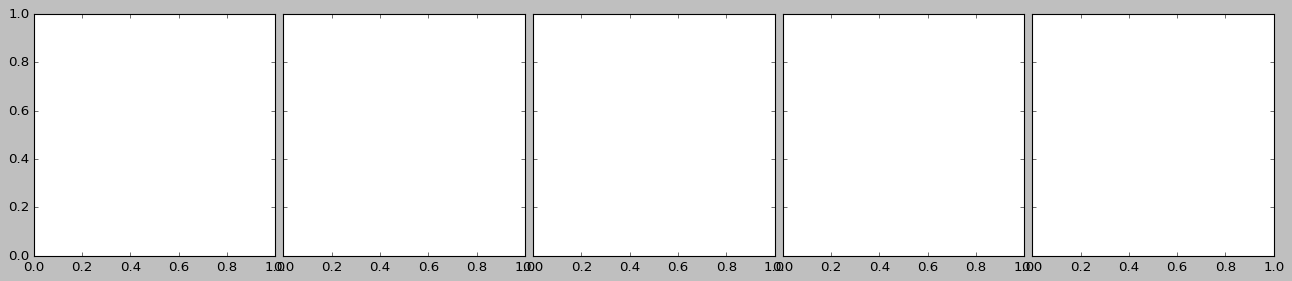

In [ ]:
# show_progress_over_time((0, 100, 'ONE_POINT', 100, 500), grid=(1,5))